# PART 5

Haikal Ali_1103223071_TK46GAB

# Chapter 5 - Classification


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import bs

## 1. Classification

**Classification** adalah bentuk supervised learning untuk memprediksi kategori suatu record. Contohnya: apakah email phishing atau bukan, apakah pelanggan akan churn atau tidak, dan apakah user akan klik iklan atau tidak.

Dalam binary classification, target biasanya diprediksi sebagai **1** atau **0**. Pada beberapa kasus, output dapat memiliki lebih dari dua kategori.

Selain label kelas, banyak model classification juga menghasilkan **probability score** atau **propensity**, yaitu probabilitas record masuk ke class tertentu. Di scikit-learn, umumnya tersedia:

- `predict`: menghasilkan class.
- `predict_proba`: menghasilkan probabilitas tiap class.

Cara umum mengubah probability score menjadi keputusan:

1. Tentukan cutoff probability untuk class yang menjadi perhatian.
2. Estimasi probabilitas record masuk ke class tersebut.
3. Jika probabilitas lebih tinggi dari cutoff, record dimasukkan ke class tersebut.

Semakin tinggi cutoff, semakin sedikit record yang diprediksi sebagai 1. Semakin rendah cutoff, semakin banyak record yang diprediksi sebagai 1.

## 2. More Than Two Categories

Sebagian besar masalah classification bersifat binary. Namun, ada juga classification dengan lebih dari dua outcome. Contoh pada kontrak pelanggan:

- **Y = 2**: pelanggan churn.
- **Y = 1**: pelanggan lanjut month-to-month.
- **Y = 0**: pelanggan menandatangani kontrak jangka panjang baru.

Masalah multiclass seperti ini sering dapat dipecah menjadi beberapa masalah binary menggunakan conditional probability. Contohnya:

1. Prediksi apakah **Y = 0** atau **Y > 0**.
2. Jika **Y > 0**, prediksi apakah **Y = 1** atau **Y = 2**.

Pendekatan ini sering menguntungkan, terutama ketika satu kategori jauh lebih umum daripada kategori lain.

## 3. Naive Bayes

Naive Bayes menggunakan probabilitas kemunculan nilai predictor, dengan syarat outcome tertentu, untuk memperkirakan probabilitas outcome berdasarkan predictor.

| Istilah | Makna |
|---|---|
| Conditional probability | Probabilitas suatu event terjadi jika event lain sudah diketahui terjadi. |
| Posterior probability | Probabilitas outcome setelah informasi predictor diperhitungkan. |

Dalam exact Bayesian classification, langkahnya adalah:

1. Cari record lain dengan profil predictor yang sama.
2. Lihat class apa yang paling sering muncul pada record tersebut.
3. Assign class tersebut ke record baru.

Masalahnya, ketika jumlah predictor banyak, exact match menjadi sangat jarang. Karena itu digunakan pendekatan naive Bayes.

### Naive Solution

Naive Bayes tidak hanya mencari record yang sama persis. Model menggunakan seluruh data dan membuat asumsi bahwa predictor saling independent secara conditional terhadap outcome.

Untuk binary response **Y = i**, algoritmanya:

1. Estimasi conditional probability untuk setiap predictor: $P(X_j \mid Y=i)$.
2. Kalikan probabilitas tersebut dengan proporsi record pada class **Y = i**.
3. Ulangi untuk semua class.
4. Hitung probabilitas outcome dengan membandingkan nilai tiap class terhadap totalnya.
5. Assign record ke class dengan probabilitas terbesar.

Rumus exact Bayes:

$$P(Y=i \mid X_1, X_2, ..., X_p) = \frac{P(Y=i)P(X_1, ..., X_p \mid Y=i)}{P(Y=0)P(X_1, ..., X_p \mid Y=0) + P(Y=1)P(X_1, ..., X_p \mid Y=1)}$$

Dengan asumsi naive Bayes:

$$P(Y=i \mid X_1, X_2, ..., X_p) = \frac{P(Y=i)P(X_1 \mid Y=i)...P(X_p \mid Y=i)}{P(Y=0)P(X_1 \mid Y=0)...P(X_p \mid Y=0) + P(Y=1)P(X_1 \mid Y=1)...P(X_p \mid Y=1)}$$

Disebut “naive” karena model mengasumsikan setiap predictor independent dari predictor lain setelah outcome diketahui.

In [21]:
loan_data = pd.read_csv('/content/loan3000.csv')

In [23]:
if 'loan_data' in globals():
  predictors = ['purpose_', 'dti', 'payment_inc_ratio']
  outcome = 'outcome'

  X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='')
  y = loan_data[outcome]

  naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
  naive_model.fit(X, y)
else:
  print('Data loan_data tidak dicantumkan lengkap di PDF.')

Output model Naive Bayes berisi conditional probability $P(X_j \mid Y=i)$. Pada Python, conditional probability dapat diturunkan dari properti `feature_log_prob_` pada model yang sudah dilatih.

In [24]:
if 'loan_data' in globals() and 'naive_model' in globals():
  new_loan = X.loc[146:146, :]

  print('predicted class: ', naive_model.predict(new_loan)[0])
  probabilities = pd.DataFrame(naive_model.predict_proba(new_loan),
                               columns=naive_model.classes_)
  print('predicted probabilities')
  print(probabilities)
else:
  print('Data loan_data tidak dicantumkan lengkap di PDF.')

predicted class:  paid off
predicted probabilities
    default  paid off
0  0.490018  0.509982


Pada contoh materi, record pinjaman baru dengan tujuan **small_business**, status rumah **MORTGAGE**, dan lama kerja **> 1 Year** diprediksi sebagai **default**. Probabilitas posterior default sekitar **0.6537**, sedangkan paid off sekitar **0.3463**.

Naive Bayes dikenal dapat menghasilkan estimasi probabilitas yang bias. Namun, jika tujuannya adalah memberi ranking record berdasarkan peluang **Y = 1**, estimasi yang benar-benar unbiased tidak selalu diperlukan.

### Numeric Predictor Variables

Naive Bayes standar bekerja dengan predictor kategorikal. Untuk predictor numerik, ada dua pendekatan:

1. Melakukan binning dan mengubah predictor numerik menjadi kategori.
2. Menggunakan probability model, misalnya normal distribution, untuk mengestimasi $P(X_j \mid Y=i)$.

Jika suatu kategori predictor tidak ada pada training data, probabilitas outcome bisa menjadi nol. Banyak implementasi Naive Bayes memakai **Laplace smoothing** untuk mencegah hal ini.

**Key Ideas:**

- Naive Bayes bekerja dengan predictor dan outcome kategorikal.
- Model melihat kategori predictor mana yang paling mungkin muncul dalam setiap kategori outcome.
- Informasi tersebut dibalik untuk memperkirakan probabilitas outcome berdasarkan nilai predictor.

## 4. Discriminant Analysis

**Discriminant analysis** adalah salah satu statistical classifier paling awal. Varian yang paling umum adalah **Linear Discriminant Analysis (LDA)**.

| Istilah | Makna |
|---|---|
| Covariance | Ukuran sejauh mana dua variabel berubah bersama. |
| Discriminant function | Fungsi yang memaksimalkan pemisahan antar class. |
| Discriminant weights | Skor hasil discriminant function yang digunakan untuk mengestimasi class. |

LDA tidak sama dengan **Latent Dirichlet Allocation**, walaupun keduanya sama-sama sering disingkat LDA.

### Covariance Matrix

Covariance antara dua variabel **x** dan **z** mengukur hubungan keduanya:

$$s_{x,z} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(z_i - \bar{z})}{n-1}$$

Nilai positif menunjukkan hubungan positif, sedangkan nilai negatif menunjukkan hubungan negatif.

Covariance matrix untuk dua variabel berisi variance pada diagonal dan covariance pada posisi luar diagonal:

$$\Sigma = \begin{bmatrix} s_x^2 & s_{x,z} \\ s_{z,x} & s_z^2 \end{bmatrix}$$

Covariance matrix digunakan pada standardisasi multivariat dan berkaitan dengan **Mahalanobis distance**.

### Fisher's Linear Discriminant

LDA mencari kombinasi linear predictor yang memaksimalkan pemisahan antar group. Untuk dua predictor numerik **x** dan **z**, fungsi linear dapat ditulis:

$$w_xx + w_zz$$

Tujuannya adalah memaksimalkan rasio:

$$\frac{SS_{between}}{SS_{within}}$$

Artinya, model mencari pemisahan antar group yang besar, tetapi variasi di dalam group kecil.

In [25]:
loan3000 = pd.read_csv('/content/loan3000.csv')

In [26]:
if 'loan3000' in globals():
  loan3000.outcome = loan3000.outcome.astype('category')

  predictors = ['borrower_score', 'payment_inc_ratio']
  outcome = 'outcome'

  X = loan3000[predictors]
  y = loan3000[outcome]

  loan_lda = LinearDiscriminantAnalysis()
  loan_lda.fit(X, y)

  pd.DataFrame(loan_lda.scalings_, index=X.columns)
else:
  print('Data loan3000 tidak dicantumkan lengkap di PDF.')

Jika predictor dinormalisasi sebelum LDA, discriminant weights dapat digunakan sebagai ukuran variable importance.

In [28]:
if 'loan3000' in globals() and 'loan_lda' in globals():
  pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                      columns=loan_lda.classes_)
  pred.head()
else:
  print('Data loan3000 tidak dicantumkan lengkap di PDF.')

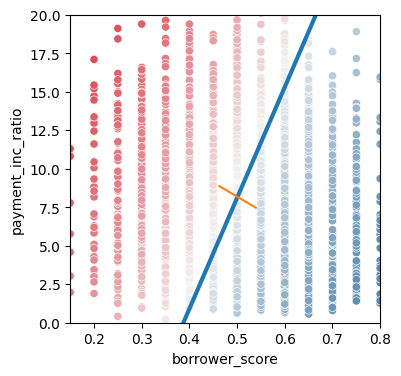

In [29]:
if 'loan3000' in globals() and 'loan_lda' in globals():
  center = np.mean(loan_lda.means_, axis=0)
  slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
  intercept = center[1] - center[0] * slope

  x_0 = (0 - intercept) / slope
  x_20 = (20 - intercept) / slope

  lda_df = pd.concat([loan3000, pred['default']], axis=1)

  fig, ax = plt.subplots(figsize=(4, 4))
  sns.scatterplot(x='borrower_score', y='payment_inc_ratio',
                  hue='default', data=lda_df,
                  palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                  ax=ax, legend=False)
  ax.set_ylim(0, 20)
  ax.set_xlim(0.15, 0.8)
  ax.plot((x_0, x_20), (0, 20), linewidth=3)
  ax.plot(*loan_lda.means_.transpose())
else:
  print('Data loan3000 tidak dicantumkan lengkap di PDF.')

Pada visualisasi LDA, garis decision boundary membagi ruang predictor menjadi dua region. Titik yang berada lebih jauh dari garis memiliki probabilitas class yang lebih jauh dari 0.5, sehingga prediksinya lebih yakin.

**Key Ideas:**

- Discriminant analysis dapat bekerja dengan predictor continuous atau categorical serta outcome categorical.
- LDA menggunakan covariance matrix untuk menghitung linear discriminant function.
- Fungsi ini menghasilkan score untuk menentukan class record.

## 5. Logistic Regression

**Logistic regression** mirip dengan multiple linear regression, tetapi outcome-nya binary. Model ini populer karena cepat dihitung dan dapat menghasilkan probabilitas class.

| Istilah | Makna |
|---|---|
| Logit | Fungsi yang memetakan probabilitas class ke rentang $-\infty$ sampai $+\infty$. |
| Odds | Rasio antara success dan nonsuccess. |
| Log odds | Respons dalam model yang sudah ditransformasi menjadi linear. |

Logistic regression adalah structured model, bukan data-centric approach seperti KNN atau naive Bayes.

### Logistic Response Function dan Logit

Outcome dianggap sebagai probabilitas **p** bahwa label bernilai 1. Jika langsung dimodelkan linear:

$$p = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_qx_q$$

maka hasilnya tidak dijamin berada antara 0 dan 1. Karena itu digunakan logistic response function:

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_qx_q)}}$$

Odds didefinisikan sebagai:

$$Odds(Y=1) = \frac{p}{1-p}$$

Log odds atau logit menjadi:

$$log(Odds(Y=1)) = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_qx_q$$

Dengan transformasi ini, model linear dapat digunakan untuk memprediksi probabilitas.

### Logistic Regression dan GLM

Logistic regression adalah contoh **Generalized Linear Model (GLM)**. GLM memiliki dua komponen utama:

- Probability distribution atau family. Pada logistic regression: **binomial**.
- Link function. Pada logistic regression: **logit**.

In [35]:
if 'loan_data' in globals():
  predictors = ['payment_inc_ratio', 'purpose_', 'borrower_score', 'dti',
                'Unnamed: 0']
  outcome = 'outcome'

  X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='',
                     drop_first=True)
  y = loan_data[outcome]

  logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
  logit_reg.fit(X, y)
else:
  print('Data loan_data tidak dicantumkan lengkap di PDF.')

Pada scikit-learn, `predict` menghasilkan label class, sedangkan `predict_proba` menghasilkan probabilitas sesuai urutan class pada atribut `classes_`.

In [37]:
if 'loan_data' in globals() and 'logit_reg' in globals():
  pred = pd.DataFrame(logit_reg.predict_proba(X),
                      columns=logit_reg.classes_)
  pred.describe()
else:
  print('Data loan_data tidak dicantumkan lengkap di PDF.')

Nilai probabilitas berada pada rentang 0 sampai 1. Nilai tersebut belum otomatis menjadi keputusan final. Misalnya, cutoff 0.5 dapat digunakan untuk menentukan default atau paid off, tetapi untuk rare class sering diperlukan cutoff yang lebih rendah.

### Interpreting the Coefficients and Odds Ratios

Koefisien logistic regression berada pada skala log odds. Untuk binary predictor **X**, odds ratio ditulis:

$$odds\ ratio = \frac{Odds(Y=1 \mid X=1)}{Odds(Y=1 \mid X=0)}$$

Jika odds ratio = 2, maka odds bahwa **Y = 1** saat **X = 1** adalah dua kali lebih besar dibanding saat **X = 0**.

Koefisien $\beta_j$ dalam logistic regression adalah log dari odds ratio untuk $X_j$.

Contoh dari materi: coefficient `purpose_small_business` sebesar **1.21526**, sehingga odds ratio-nya sekitar $exp(1.21526) \approx 3.4$. Artinya, loan untuk small business lebih berisiko default dibanding loan untuk credit card debt.

### Linear dan Logistic Regression

Linear regression dan logistic regression sama-sama memakai bentuk linear parametric antara predictor dan response. Namun, logistic regression berbeda dalam dua hal:

1. Cara fitting model: logistic regression tidak menggunakan least squares.
2. Cara analisis residual: output logistic regression bersifat binary sehingga residualnya berbeda dari linear regression.

Logistic regression dilatih menggunakan **Maximum Likelihood Estimation (MLE)**. MLE mencari parameter yang membuat data yang diamati menjadi paling mungkin terjadi menurut model.

In [38]:
if 'loan_data' in globals() and 'X' in globals() and 'y' in globals():
  y_numbers = [1 if yi == 'default' else 0 for yi in y]

  logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1),
                        family=sm.families.Binomial())
  logit_result = logit_reg_sm.fit()
  logit_result.summary()
else:
  print('Data loan_data tidak dicantumkan lengkap di PDF.')

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

Output logistic regression dapat menampilkan standard error, z-value, p-value, deviance, dan AIC. Dalam konteks data science, p-value lebih sering digunakan sebagai indikator relatif variable importance, bukan sebagai ukuran formal final untuk mengambil keputusan.

Logistic regression biasanya dievaluasi dengan metric classification, bukan RMSE atau R-squared.

In [39]:
if 'loan_data' in globals():
  formula = ('outcome ~ bs(payment_inc_ratio, df=4) + purpose_ + ' +
             'home_ + emp_len_ + bs(borrower_score, df=4)')
  model = smf.glm(formula=formula, data=loan_data,
                  family=sm.families.Binomial())
  results = model.fit()
  results.summary()
else:
  print('Data loan_data tidak dicantumkan lengkap di PDF.')

PatsyError: Error evaluating factor: NameError: name 'emp_len_' is not defined
    outcome ~ bs(payment_inc_ratio, df=4) + purpose_ + home_ + emp_len_ + bs(borrower_score, df=4)
                                                               ^^^^^^^^

### Analysis of Residuals

Pada logistic regression, partial residual plot biasanya memiliki dua kumpulan titik: satu untuk response 1 dan satu untuk response 0. Ini terjadi karena output aktual adalah binary, sementara prediksi berada pada skala logit yang finite.

Partial residual pada logistic regression kurang bernilai dibanding pada linear regression, tetapi masih berguna untuk melihat nonlinear behavior dan record yang sangat influential.

**Key Ideas:**

- Logistic regression seperti linear regression, tetapi outcome-nya binary.
- Model menggunakan transformasi log odds agar hubungan dapat ditulis linear.
- Setelah model linear dilatih, log odds dikembalikan menjadi probabilitas.
- Logistic regression populer karena cepat dan mudah digunakan untuk scoring data baru.

## 6. Evaluating Classification Models

Classification model biasanya dilatih, lalu diuji pada holdout sample untuk menilai performa pada data baru.

| Istilah | Makna |
|---|---|
| Accuracy | Proporsi kasus yang diklasifikasikan dengan benar. |
| Confusion matrix | Tabel jumlah prediksi benar dan salah berdasarkan actual dan predicted class. |
| Sensitivity / Recall | Proporsi semua class 1 yang berhasil diklasifikasikan sebagai 1. |
| Specificity | Proporsi semua class 0 yang berhasil diklasifikasikan sebagai 0. |
| Precision | Proporsi prediksi class 1 yang benar-benar class 1. |
| ROC curve | Plot sensitivity terhadap specificity. |
| Lift | Ukuran efektivitas model dalam menemukan class 1 yang relatif rare pada berbagai cutoff. |

Accuracy:

$$accuracy = \frac{\sum TruePositive + \sum TrueNegative}{SampleSize}$$

### Confusion Matrix

Confusion matrix menampilkan actual response pada baris dan predicted response pada kolom. Elemen diagonal menunjukkan prediksi benar, sedangkan elemen luar diagonal menunjukkan prediksi salah.

In [40]:
if 'logit_reg' in globals() and 'X' in globals() and 'y' in globals():
  pred = logit_reg.predict(X)
  pred_y = logit_reg.predict(X) == 'default'
  true_y = y == 'default'

  true_pos = true_y & pred_y
  true_neg = ~true_y & ~pred_y
  false_pos = ~true_y & pred_y
  false_neg = true_y & ~pred_y

  conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)],
                           [np.sum(false_pos), np.sum(true_neg)]],
                          index=['Y = default', 'Y = paid off'],
                          columns=['Yhat = default', 'Yhat = paid off'])
  conf_mat
else:
  print('Model logistic regression atau data tidak tersedia.')

### The Rare Class Problem

Pada banyak kasus, class yang menarik justru rare. Contoh: fraudulent claim, pembeli di website, atau default loan.

Jika class 1 sangat jarang, model dengan accuracy tinggi bisa saja tidak berguna. Misalnya, jika hanya 0.1% pengunjung website membeli barang, model yang selalu memprediksi “tidak membeli” memiliki accuracy 99.9%, tetapi tidak membantu menemukan pembeli.

### Precision, Recall, dan Specificity

Precision:

$$precision = \frac{\sum TruePositive}{\sum TruePositive + \sum FalsePositive}$$

Recall / sensitivity:

$$recall = \frac{\sum TruePositive}{\sum TruePositive + \sum FalseNegative}$$

Specificity:

$$specificity = \frac{\sum TrueNegative}{\sum TrueNegative + \sum FalsePositive}$$

In [41]:
if 'logit_reg' in globals() and 'X' in globals() and 'y' in globals():
  conf_mat = confusion_matrix(y, logit_reg.predict(X))

  print('Precision', conf_mat[0, 0] / sum(conf_mat[:, 0]))
  print('Recall', conf_mat[0, 0] / sum(conf_mat[0, :]))
  print('Specificity', conf_mat[1, 1] / sum(conf_mat[1, :]))

  precision_recall_fscore_support(y, logit_reg.predict(X),
                                  labels=['default', 'paid off'])
else:
  print('Model logistic regression atau data tidak tersedia.')

Precision 0.9279346210995543
Recall 0.8643598615916955
Specificity 0.9376205787781351


### ROC Curve

ROC curve menunjukkan trade-off antara recall dan specificity ketika cutoff classification berubah.

Proses membuat ROC curve:

1. Urutkan record berdasarkan predicted probability sebagai class 1, dari paling besar ke paling kecil.
2. Hitung cumulative specificity dan recall berdasarkan urutan tersebut.

Classifier yang tidak lebih baik dari random chance berada pada garis diagonal. Classifier yang sangat baik mendekati pojok kiri atas.

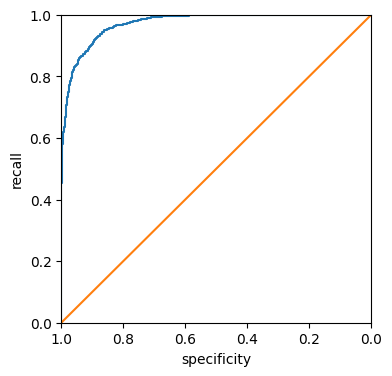

In [42]:
if 'logit_reg' in globals() and 'X' in globals() and 'y' in globals():
  fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0],
                                  pos_label='default')

  roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

  ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
  ax.set_ylim(0, 1)
  ax.set_xlim(1, 0)
  ax.plot((1, 0), (0, 1))
  ax.set_xlabel('specificity')
  ax.set_ylabel('recall')
else:
  print('Model logistic regression atau data tidak tersedia.')

### Precision-Recall Curve

Selain ROC curve, precision-recall curve juga berguna. PR curve sangat berguna untuk mengevaluasi data dengan outcome yang sangat tidak seimbang.

### AUC

AUC adalah area under the ROC curve. Semakin besar AUC, semakin efektif classifier.

- **AUC = 1** berarti classifier sempurna.
- **AUC = 0.5** berarti classifier tidak efektif dan setara random chance.

Pada contoh materi, model loan memiliki AUC sekitar **0.69**, sehingga classifier-nya relatif lemah.

In [43]:
if 'logit_reg' in globals() and 'X' in globals() and 'y' in globals() and 'roc_df' in globals():
  print(np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)))
  print(roc_auc_score([1 if yi == 'default' else 0 for yi in y],
                      logit_reg.predict_proba(X)[:, 0]))
else:
  print('Model logistic regression atau data ROC tidak tersedia.')

0.9726587968268449
0.972658796826845


### False Positive Rate Confusion

False positive dan false negative rates sering tertukar dengan specificity atau sensitivity. Pada beberapa konteks, false positive rate berarti proporsi true negative yang dites positif. Pada konteks lain, istilah ini bisa berarti proporsi positive signal yang sebenarnya true negative.

### Lift

AUC lebih baik daripada accuracy sederhana, tetapi belum sepenuhnya menyelesaikan rare class problem. Pada rare class, cutoff sering perlu diturunkan agar lebih banyak class 1 terdeteksi.

**Lift** mengukur seberapa baik model menemukan class 1 dibanding pemilihan acak. Contoh: jika top 10% record dengan probabilitas tertinggi menghasilkan response 0.3%, sementara baseline random hanya 0.1%, maka lift pada decile tersebut adalah 3.

Lift chart membantu melihat konsekuensi dari berbagai cutoff probability. Ini sering digunakan ketika resource terbatas, misalnya memilih tax return mana yang perlu diaudit.

**Key Ideas:**

- Accuracy hanya langkah awal dalam evaluasi model.
- Recall, specificity, dan precision menilai karakteristik performa yang lebih spesifik.
- AUC mengukur kemampuan model membedakan 1 dari 0.
- Lift mengukur efektivitas model menemukan class 1, sering dihitung per decile.

## 7. Strategies for Imbalanced Data

Imbalanced data terjadi ketika outcome yang menarik jarang muncul. Contoh: pembelian di website, insurance fraud, dan default loan.

| Istilah | Makna |
|---|---|
| Undersample / Downsample | Menggunakan lebih sedikit record dari class yang dominan. |
| Oversample / Upsample | Menggunakan lebih banyak record dari class rare, termasuk bootstrapping jika perlu. |
| Up weight / Down weight | Memberi bobot lebih besar atau lebih kecil pada class tertentu. |
| Data generation | Membuat record baru yang sedikit berbeda dari record sumber. |
| z-score | Nilai hasil standardization. |
| K | Jumlah neighbor dalam nearest neighbor calculation. |

### Undersampling

Jika data cukup banyak, salah satu solusi adalah melakukan undersampling pada class yang dominan agar training data lebih seimbang.

Ide dasarnya: class dominan memiliki banyak record redundant. Dataset yang lebih kecil dan seimbang dapat memperbaiki performa model serta memudahkan eksplorasi.

Pada contoh materi, full training set memiliki sekitar **19%** loan default. Saat model dilatih pada full data yang tidak seimbang, hanya sekitar **0.39%** loan yang diprediksi default. Ini terjadi karena record paid off mendominasi model.

In [ ]:
if 'full_train_set' in globals():
  print('percentage of loans in default: ',
        100 * np.mean(full_train_set.outcome == 'default'))
else:
  print('Data full_train_set tidak dicantumkan lengkap di PDF.')

In [ ]:
if 'full_train_set' in globals():
  predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_',
                'dti', 'revol_bal', 'revol_util']
  outcome = 'outcome'

  X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='',
                     drop_first=True)
  y = full_train_set[outcome]

  full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
  full_model.fit(X, y)

  print('percentage of loans predicted to default: ',
        100 * np.mean(full_model.predict(X) == 'default'))
else:
  print('Data full_train_set tidak dicantumkan lengkap di PDF.')

### Oversampling dan Up/Down Weighting

Kritik terhadap undersampling adalah sebagian data dibuang. Jika dataset kecil dan rare class hanya memiliki ratusan atau ribuan record, membuang data dari class dominan berisiko menghilangkan informasi penting.

Alternatifnya:

- **Oversampling** rare class dengan sampling with replacement.
- **Weighting**, yaitu memberi bobot lebih besar pada rare class atau bobot lebih kecil pada class dominan.

In [ ]:
if 'full_train_set' in globals() and 'X' in globals() and 'y' in globals():
  default_wt = 1 / np.mean(full_train_set.outcome == 'default')
  wt = [default_wt if outcome == 'default' else 1
        for outcome in full_train_set.outcome]

  full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
  full_model.fit(X, y, sample_weight=wt)

  print('percentage of loans predicted to default (weighting): ',
        100 * np.mean(full_model.predict(X) == 'default'))
else:
  print('Data full_train_set tidak dicantumkan lengkap di PDF.')

Pada weighting, bobot loan default diset menjadi $1/p$, dengan $p$ sebagai probability default. Loan nondefault memiliki bobot 1. Hasilnya, jumlah bobot default dan nondefault menjadi relatif seimbang.

Weighting menjadi alternatif untuk oversampling rare class maupun downsampling dominant class.

### Data Generation

Data generation adalah variasi dari upsampling. Record baru dibuat dengan sedikit perturbation dari record yang sudah ada.

SMOTE atau **Synthetic Minority Oversampling Technique** membuat synthetic record dengan mencari neighbor yang mirip dengan record rare class, lalu membuat record baru sebagai rata-rata berbobot antara record asli dan neighbor-nya.

Python package `imbalanced-learn` menyediakan berbagai metode over-sampling dan under-sampling dengan API yang kompatibel dengan scikit-learn.

### Cost-Based Classification

Accuracy dan AUC tidak selalu cukup untuk memilih classification rule. Dalam praktik, false positive dan false negative sering memiliki cost berbeda.

Jika cost default loan adalah **C** dan return loan paid off adalah **R**, expected return dapat ditulis:

$$expected\ return = P(Y=0) \times R + P(Y=1) \times C$$

Daripada hanya memberi label default atau paid off, lebih masuk akal menentukan apakah loan memiliki expected return positif. Probability of default hanyalah langkah antara, sedangkan metric bisnis akhirnya adalah expected profit.

### Exploring the Predictions

Satu metric seperti AUC tidak dapat menilai semua aspek kecocokan model. Materi membandingkan decision rule dari beberapa model pada data loan dengan dua predictor: `borrower_score` dan `payment_inc_ratio`.

Model yang dibandingkan:

- Linear Discriminant Analysis (LDA)
- Logistic linear regression
- Logistic regression dengan generalized additive model (GAM)
- Tree model

LDA dan logistic linear regression menghasilkan rule yang hampir identik. Tree model menghasilkan rule yang paling tidak regular. GAM menjadi kompromi antara tree model dan linear model.

**Key Ideas:**

- Highly imbalanced data bermasalah untuk classification algorithm.
- Strategi umum adalah menyeimbangkan training data dengan undersampling class dominan atau oversampling rare class.
- Jika jumlah class 1 masih terlalu kecil, rare cases dapat di-bootstrap atau dibuat synthetic data dengan SMOTE.
- Imbalanced data biasanya berarti salah satu class memiliki nilai bisnis lebih tinggi, sehingga rasio nilai tersebut harus masuk ke assessment metric.

## 8. Summary

Classification adalah proses memprediksi kategori suatu record. Masalahnya bisa binary atau multiclass. Pada binary classification, class yang menjadi perhatian biasanya diberi label **1**, sedangkan class yang lebih umum diberi label **0**.

Banyak masalah classification membutuhkan estimasi propensity score, yaitu probabilitas record masuk ke class yang menjadi perhatian. Ketika class yang penting relatif rare, accuracy saja tidak cukup untuk evaluasi. Metric seperti confusion matrix, precision, recall, specificity, ROC, AUC, dan lift diperlukan agar model tidak terlihat bagus hanya karena mayoritas record berasal dari class 0.